# Neighbourhood enrichment

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq

import sys
sys.path.append('../../../phenotyping')
from phenotyping_utils import generate_anndata_from_cell_table
import pickle
from collections import defaultdict
from tqdm import tqdm
import seaborn as sns

## Generate adata

In [3]:
adata = generate_anndata_from_cell_table(cell_table_path='../../../CellTable_CleanCohort/updated_cell_table_Ki67.csv', biosamples_path='../../../CellTable_CleanCohort/CleanCohort_Metadata.csv')

/Users/linus/opt/miniconda3/envs/imc_analysis/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [4]:
nonresponderpp = adata[adata.obs['Response']=='Non-Responder']

## Generate the matrix of contact for each fov

In [ ]:
def neighbours(fovs):
    '''It returns the matrix of contact for each fov'''
    store = {}    
    for ID in  set(fovs):
        sub_adata = adata[adata.obs.acquisition_ID==ID]#select one acquisition
        sq.gr.spatial_neighbors(sub_adata,coord_type='grid')
        sq.gr.nhood_enrichment(sub_adata, cluster_key='Pixie')
        A = sub_adata.uns['Pixie_nhood_enrichment']['zscore']
        a = np.array(sub_adata.obs['Pixie'].cat.categories)#label list
        fov_neighbour = pd.DataFrame(A,index=a,columns=a)
        store[ID]=fov_neighbour.fillna(0)
    return store

In [ ]:
# takes 39 mins to run (or more/less depending on your computer)
neigh_all = neighbours(nonresponderpp.obs.acquisition_ID.drop_duplicates())

###DO NOT RUN if unsure. Data are saved
# with open('neighbours_matrix.pkl', 'wb') as f:
#     pickle.dump(neigh_all, f)

# ## Or load the precomputed data
# with open('neighbours_matrix.pkl', 'rb') as f:
#     neigh_all = pickle.load(f)

/Users/linus/opt/miniconda3/envs/imc_analysis/lib/python3.11/site-packages/squidpy/gr/_utils.py:203: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
  0%|          | 0/1000 [00:00<?, ?/s]/Users/linus/opt/miniconda3/envs/imc_analysis/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/linus/opt/miniconda3/envs/imc_analysis/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
100%|██████████| 1000/1000 [00:07<00:00, 142.29/s]
/Users/linus/opt/miniconda3

In [8]:
sample=nonresponderpp#nonresponderpp#pre
labels_list = sample.obs.Pixie.unique()
X = []
ids = []
core_ids = set(sample.obs.acquisition_ID)
for id,tb in neigh_all.items():
    if id not in core_ids:
        continue
    temp_matrix = pd.DataFrame(0.,index = labels_list,columns=labels_list)
    sub_list = tb.index#label list
    tb.replace([np.inf, -np.inf], np.nan, inplace=True) # convert inf to nan, next line everything is replaced with 0
    temp_matrix.loc[sub_list,sub_list]=tb
    temp_values = temp_matrix.values
    X +=[temp_values]
    ids+=[id]
y = np.vectorize(dict(sample.obs[['acquisition_ID','Sample_Type_(pre/post treatment)']].values).get)(ids) #Change for 'Response' when analysing 'pre'
X = np.array(X)

## Plot

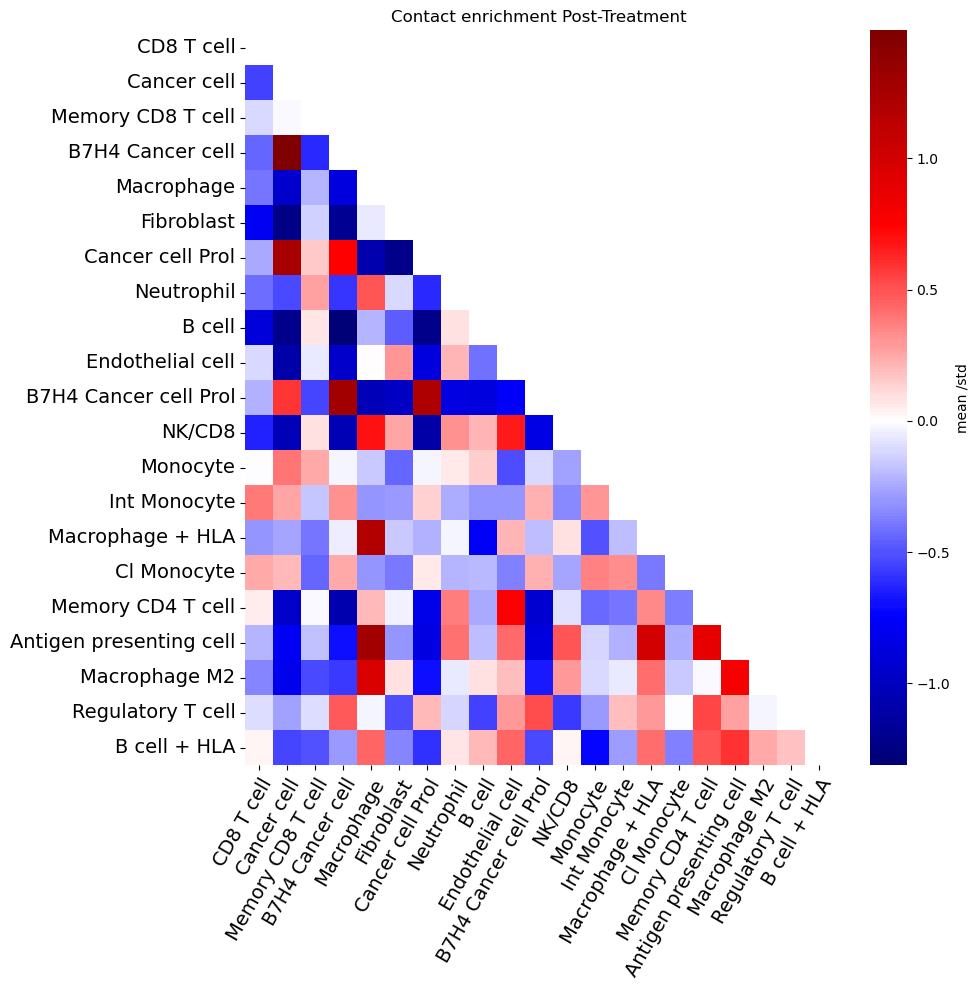

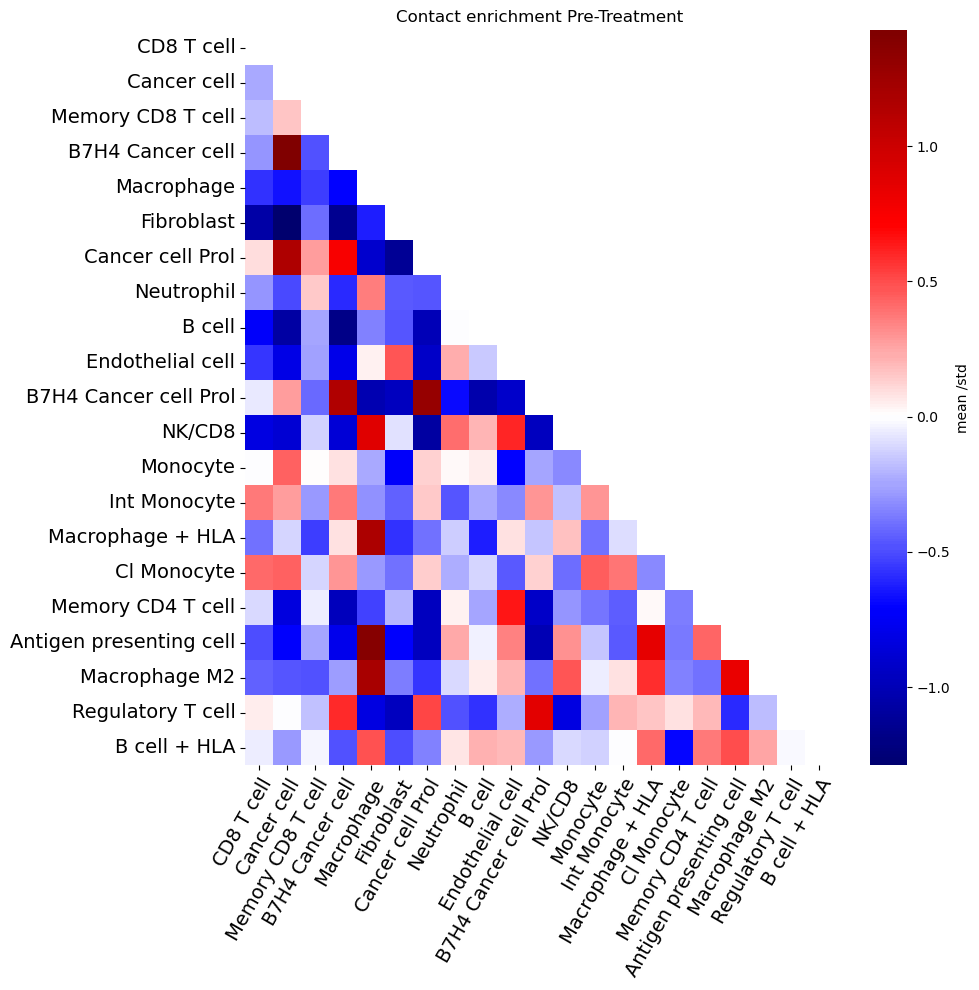

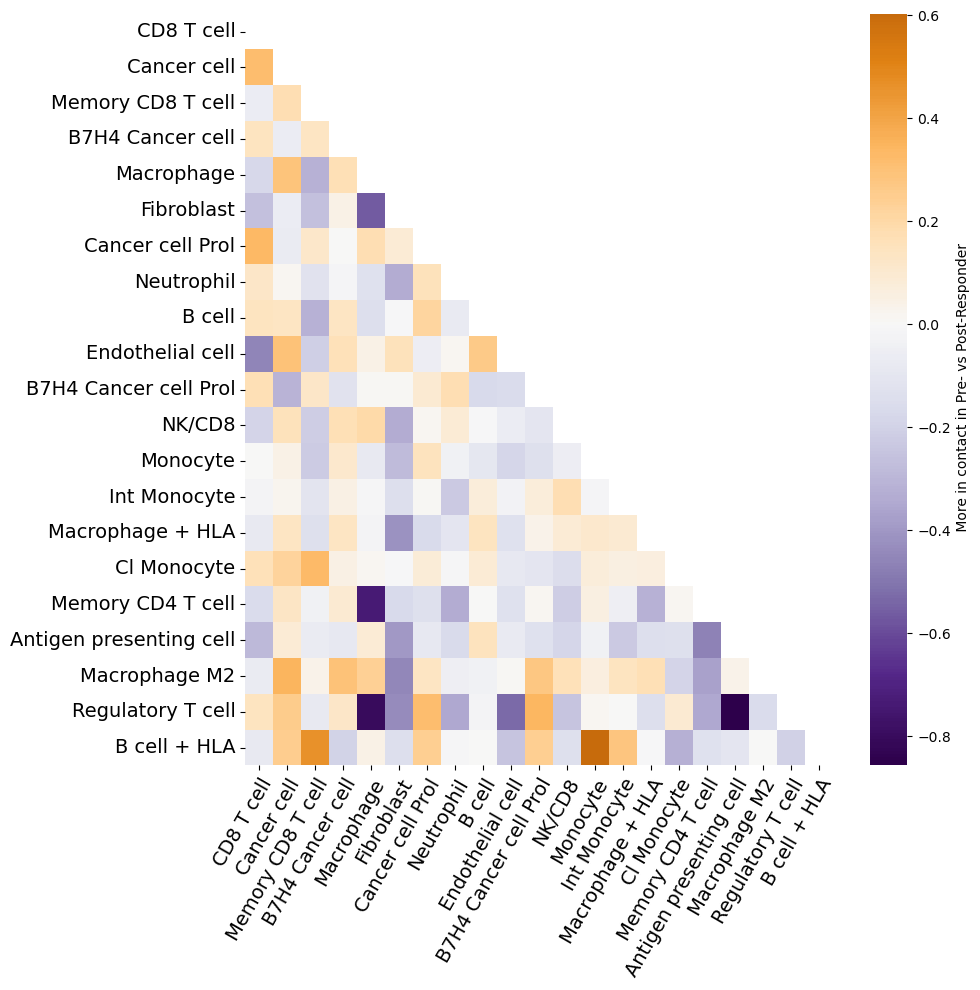

In [9]:
aux = X[y == 'post']
mean_nR = pd.DataFrame((np.nanmean(aux,axis = 0))/np.nanstd(aux,axis = 0),index = labels_list,columns=labels_list)
# Create a mask using numpy's triu function
mask1 = np.triu(np.ones_like(mean_nR, dtype=bool))
np.fill_diagonal(mean_nR.values,0)

aux = X[y == 'pre']
mean_pCr = pd.DataFrame(np.nanmean(aux,axis = 0)/np.nanstd(aux,axis = 0),index = labels_list,columns=labels_list)
# Create a mask using numpy's triu function
mask2 = np.triu(np.ones_like(mean_pCr, dtype=bool))
np.fill_diagonal(mean_pCr.values,0)


plt.figure(figsize = (10,10))
plt.title('Contact enrichment Post-Treatment')
vmax = mean_nR.abs().to_numpy().max()#vmin = -2.15,vmax = 2.15,
sns.heatmap(mean_nR,cmap='seismic',xticklabels=True,yticklabels=True,cbar = True,cbar_kws={'label':'mean /std'}, mask=mask1, center=0)
_ = plt.xticks(rotation=60,fontsize = 14,ha='right',rotation_mode='anchor')
_ = plt.yticks(fontsize = 14)
plt.tight_layout()
#plt.savefig('/home/luciana/devices/Delta_Tissue/IMC/CleanCohort/Figures/New/Neigh_NonRes_post.png',transparent = False, format='png', dpi=600, bbox_inches='tight')

plt.figure(figsize = (10,10))
plt.title('Contact enrichment Pre-Treatment')
vmax = mean_pCr.abs().to_numpy().max()
sns.heatmap(mean_pCr,cmap='seismic',xticklabels=True,yticklabels=True,cbar =True,cbar_kws={'label':'mean /std'}, mask=mask2, center=0)
_ = plt.xticks(rotation=60,fontsize = 14,ha='right',rotation_mode='anchor')
_ = plt.yticks(fontsize = 14)
plt.tight_layout()
#plt.savefig('/home/luciana/devices/Delta_Tissue/IMC/CleanCohort/Figures/New/Neigh_NonRes_pre.png',transparent = False, format='png', dpi=600, bbox_inches='tight')


sub = mean_pCr-mean_nR

mask3 = np.triu(np.ones_like(sub, dtype=bool))
np.fill_diagonal(sub.values,0)


plt.figure(figsize = (10,10))
#'PuOr_r' colormap, 'RdYlGn'
sns.heatmap(sub,cmap='PuOr_r',xticklabels=True,yticklabels=True,cbar = True,cbar_kws={'label':' More in contact in Pre- vs Post-Responder'}, mask=mask3, center=0)#,vmin = -1,vmax = 1
_ = plt.xticks(rotation=60,fontsize = 14,ha='right',rotation_mode='anchor')
_ = plt.yticks(fontsize = 14)
plt.tight_layout()
#plt.savefig('/home/luciana/devices/Delta_Tissue/IMC/CleanCohort/Figures/New/Neigh_NonRes_prevspost.png',transparent = False, format='png', dpi=600, bbox_inches='tight')